Found 92 unique subject folders. Starting data loading...
Total processed recordings: 310

Plotting preprocessing comparison for the first record...


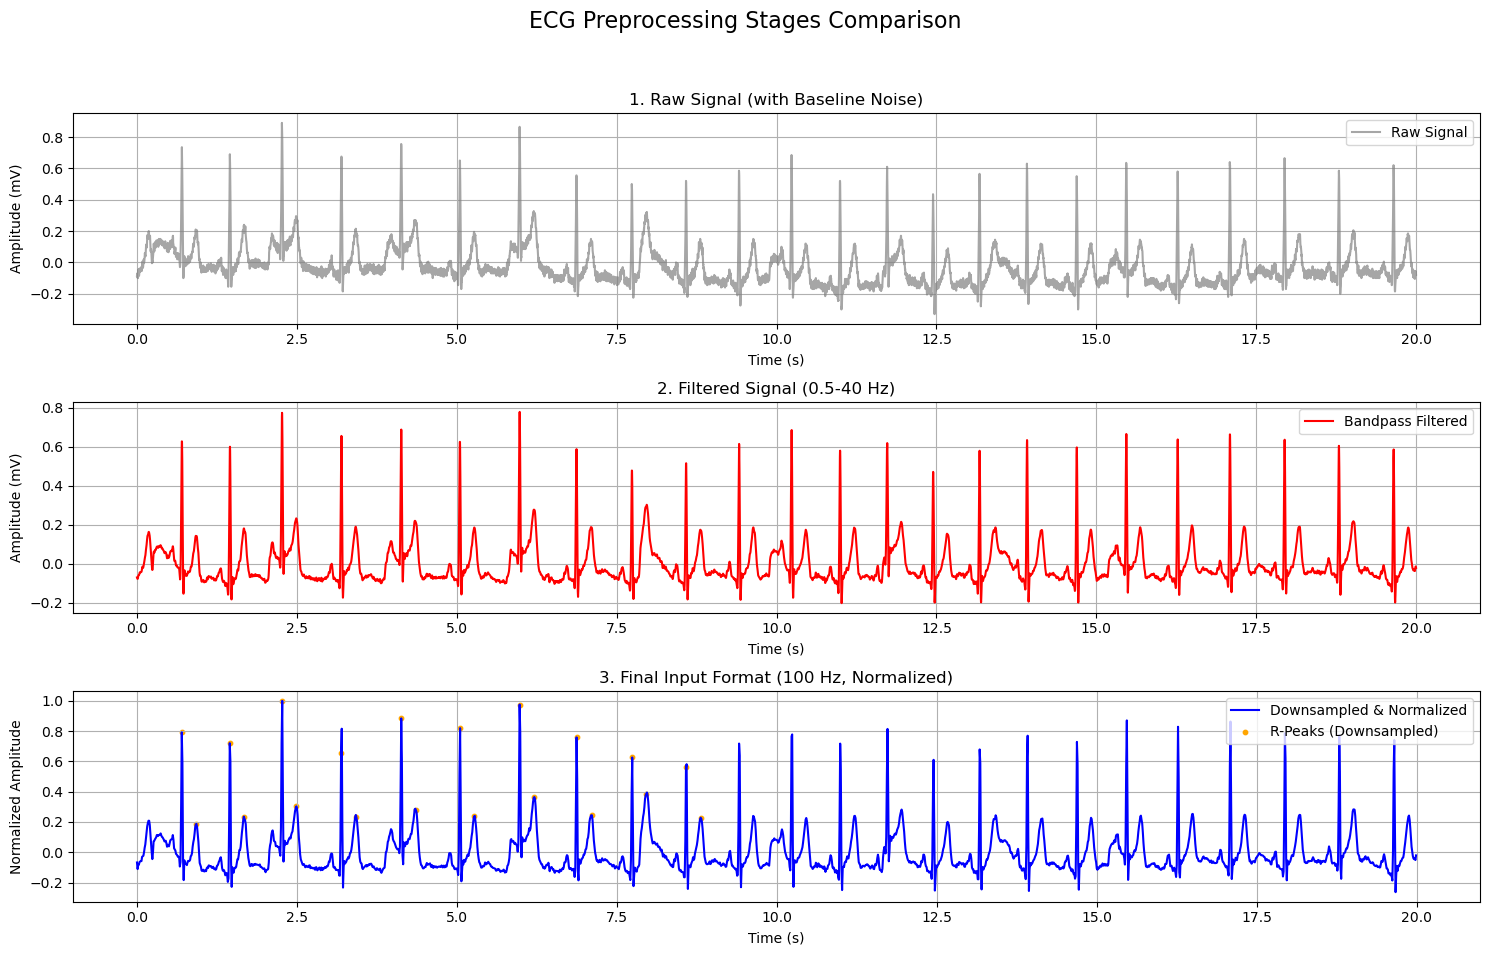


Total generated windows (samples): 23560
Window shape (Input to NN): 100 points
Heartbeat samples (y=1): 9973 (Imbalance check)

--- FINAL DATASET SPLITS ---
X_train shape: (16491, 100) (Used for learning)
X_val shape: (3535, 100) (Used for tuning)
X_test shape: (3534, 100) (Used for final honest evaluation)

Phase 1 Complete. Data saved to ./processed_data


In [24]:
# --- 1. SETUP AND IMPORTS ---
# This cell sets up the necessary libraries for signal processing and data management.
import os
import numpy as np
import pandas as pd
import wfdb # Library for reading PhysioNet files (.dat, .hea, .atr)
from scipy.signal import butter, filtfilt, resample
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt # <--- ADDED for plotting
from pathlib import Path # ADDED for robust path handling

# --- CONFIGURATION ---
# These parameters define the final output format of your training data.
# The hardware (Verilog) will be built around these numbers.
FS_RAW = 500      # Raw Sampling Frequency (from your dataset description)
FS_TARGET = 100   # Target Sampling Frequency (for low-complexity, downsampled data)
WINDOW_LENGTH_SAMPLES = 100 # Final size of the input vector for the Neural Network (100 points)
FILTER_LOW_CUT = 0.5 # High-pass filter cutoff (removes baseline wander)
FILTER_HIGH_CUT = 40 # Low-pass filter cutoff (removes high-freq noise/artifacts)

# --- CORRECTED PATH DEFINITION ---
# CRITICAL FIX: Applying the 'r' prefix to the absolute path to prevent Python from misinterpreting backslashes as escape sequences.
ECG_ROOT_PATH = Path(r'C:\Users\aaryan\Downloads\ecg-id-database-1.0.0\ecg-id-database-1.0.0') 

# --- HELPER FUNCTIONS ---

def get_butterworth_filter(low_cut, high_cut, fs, order=4):
    """Generates coefficients for a 4th-order Butterworth Bandpass Filter."""
    nyquist = 0.5 * fs
    low = low_cut / nyquist
    high = high_cut / nyquist
    # Returns (numerator, denominator) coefficients
    return butter(order, [low, high], btype='band')

def apply_filter(signal, fs):
    """Applies the Bandpass filter using filtfilt for zero phase distortion."""
    b, a = get_butterworth_filter(FILTER_LOW_CUT, FILTER_HIGH_CUT, fs)
    # filtfilt applies the filter forward and backward to avoid phase shift (timing delay)
    return filtfilt(b, a, signal)

def load_and_preprocess_record(record_base_path):
    """Loads a single record, filters, and downsamples it."""
    # wfdb.rdrecord expects the base path without the .dat extension
    try:
        # --- WFDB READ FIX: Use the full base path directly ---
        # The wfdb library should resolve the .dat and .hea files based on this prefix.
        record = wfdb.rdrecord(str(record_base_path))
        
    except Exception as e:
        print(f"Error reading record at {record_base_path}: {e}")
        # Note: If this fails, it usually means the .dat and .hea files for the specific record are missing or not named correctly.
        return None, None, None, None, None # Added returns for visualization

    # We assume the first signal (Signal 0: ECG I) is the one to use.
    raw_signal = record.p_signal[:, 0]
    fs_raw_actual = record.fs

    # 1. FILTERING (Noise Removal)
    # Apply the Bandpass filter to remove low-frequency drift and high-frequency noise.
    filtered_signal = apply_filter(raw_signal, fs_raw_actual)

    # 2. DOWNSAMPLING (Data Compression)
    # Reduces data from FS_RAW (e.g., 500Hz) to FS_TARGET (100Hz) to reduce hardware footprint.
    target_samples = int(len(filtered_signal) * FS_TARGET / fs_raw_actual)
    downsampled_signal = resample(filtered_signal, target_samples)

    # 3. NORMALIZATION (Scaling for ML)
    # Standard normalization to stabilize training. Scales values between roughly -1 and 1.
    mean_val = np.mean(downsampled_signal)
    max_abs_val = np.max(np.abs(downsampled_signal - mean_val))
    normalized_signal = (downsampled_signal - mean_val) / max_abs_val

    # Load annotations (.atr) for R-peak timing.
    # --- WFDB ANNOTATION FIX: Use the full base path directly ---
    annotations = wfdb.rdann(str(record_base_path), 'atr')
    r_peak_indices = annotations.sample
    
    # Adjust R-peak indices to match the new downsampled rate (Crucial step!)
    scale_factor = FS_TARGET / fs_raw_actual
    r_peak_indices_downsampled = (r_peak_indices * scale_factor).astype(int)

    # We return the parent folder name as the subject ID.
    subject_folder_name = Path(record_base_path).parent.name
    return normalized_signal, r_peak_indices_downsampled, subject_folder_name, raw_signal, filtered_signal 

def plot_comparison(raw_signal, filtered_signal, normalized_signal, fs_raw, fs_target, r_peaks):
    """Plots the signal at different stages of processing for visual verification."""
    
    # Create time vectors for plotting
    time_raw = np.arange(len(raw_signal)) / fs_raw
    time_filtered = np.arange(len(filtered_signal)) / fs_raw
    time_downsampled = np.arange(len(normalized_signal)) / fs_target

    plt.figure(figsize=(15, 10))
    plt.suptitle("ECG Preprocessing Stages Comparison", fontsize=16)

    # --- Plot 1: Raw Signal ---
    plt.subplot(3, 1, 1)
    plt.plot(time_raw, raw_signal, label='Raw Signal', color='gray', alpha=0.7)
    plt.title('1. Raw Signal (with Baseline Noise)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (mV)')
    plt.legend()
    plt.grid(True)

    # --- Plot 2: Filtered Signal ---
    plt.subplot(3, 1, 2)
    plt.plot(time_filtered, filtered_signal, label='Bandpass Filtered', color='red')
    # Mark R-peaks on the filtered signal (scaled to the original time)
    plt.title(f'2. Filtered Signal ({FILTER_LOW_CUT}-{FILTER_HIGH_CUT} Hz)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (mV)')
    plt.legend()
    plt.grid(True)
    
    # --- Plot 3: Final Normalized & Downsampled Signal (The NN Input Format) ---
    plt.subplot(3, 1, 3)
    plt.plot(time_downsampled, normalized_signal, label='Downsampled & Normalized', color='blue')
    # Use the downsampled peaks to show where the beats are on the final signal
    plt.scatter(time_downsampled[r_peaks], normalized_signal[r_peaks], color='orange', marker='o', label='R-Peaks (Downsampled)', s=10)
    plt.title(f'3. Final Input Format ({fs_target} Hz, Normalized)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap
    plt.show()


# --- MAIN FEATURE EXTRACTION PIPELINE ---

# --- EXECUTION ---

# 1. Collect all record paths and subject IDs from the folder structure
all_subjects_data = []

# --- PATH CHECK ---
if not ECG_ROOT_PATH.is_dir():
    print("-------------------------------------------------------------------------------------")
    print(f"FATAL ERROR: The root path '{ECG_ROOT_PATH}' was not found.")
    print("Please verify the absolute path to the 'ecg-id-database-1.0.0' folder is correct.")
    print("Execution halted.")
    print("-------------------------------------------------------------------------------------")
    subject_folders = []
else:
    # Get subject folders as Path objects (Person_01, Person_05, etc.)
    subject_folders = [f for f in ECG_ROOT_PATH.iterdir() if f.is_dir()]


print(f"Found {len(subject_folders)} unique subject folders. Starting data loading...")

# List to store the first record's original data for visualization
first_record_plot_data = None 

for subject_path in subject_folders:
    # Find all record files (e.g., 'rec_1.dat') for this subject
    # We use glob to find all files ending in .dat
    record_paths = [p for p in subject_path.glob('*.dat')]
    
    for record_path_full in record_paths:
        # wfdb.rdrecord requires the base path WITHOUT the .dat extension
        # full_record_base will now be the Path object pointing to "C:/.../Person_01/rec_1"
        full_record_base = record_path_full.with_suffix('')
        
        # Load, filter, and downsample the record
        normalized_signal, r_peaks_downsampled, subject, raw_signal, filtered_signal = load_and_preprocess_record(full_record_base)
        
        if normalized_signal is not None:
            # Capture the data from the very first processed record for plotting
            if first_record_plot_data is None:
                first_record_plot_data = {
                    'raw': raw_signal,
                    'filtered': filtered_signal,
                    'normalized': normalized_signal,
                    'r_peaks': r_peaks_downsampled,
                    'fs_raw': FS_RAW,
                    'fs_target': FS_TARGET
                }
                
            all_subjects_data.append({
                'signal': normalized_signal,
                'r_peaks': r_peaks_downsampled,
                'subject_id': subject
            })

print(f"Total processed recordings: {len(all_subjects_data)}")

# --- VISUALIZATION STEP ---
if first_record_plot_data is not None:
    print("\nPlotting preprocessing comparison for the first record...")
    plot_comparison(
        first_record_plot_data['raw'], 
        first_record_plot_data['filtered'], 
        first_record_plot_data['normalized'], 
        first_record_plot_data['fs_raw'], 
        first_record_plot_data['fs_target'],
        first_record_plot_data['r_peaks']
    )
else:
    print("\nCould not load any records for visualization.")
    
# 2. Extract X (windows), y (labels), and corresponding subject IDs for splitting
X_all = []
y_all = []
groups_all = []

for data in all_subjects_data:
    subject_windows = []
    subject_labels = []
    
    N = len(data['signal'])
    STEP = int(WINDOW_LENGTH_SAMPLES / 4)
    
    for i in range(0, N - WINDOW_LENGTH_SAMPLES, STEP):
        window = data['signal'][i:i + WINDOW_LENGTH_SAMPLES]
        
        window_contains_r_peak = False
        for peak_idx in data['r_peaks']:
            if i <= peak_idx < i + WINDOW_LENGTH_SAMPLES:
                window_contains_r_peak = True
                break
        
        X_all.append(window)
        y_all.append(1 if window_contains_r_peak else 0)
        groups_all.append(data['subject_id'])

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)
groups_all = np.array(groups_all)

print(f"\nTotal generated windows (samples): {X_all.shape[0]}")
# FIX: Check if X_all has enough dimensions before accessing index 1.
if X_all.ndim > 1:
    print(f"Window shape (Input to NN): {X_all.shape[1]} points")
else:
    # Changed the printout to be more helpful and included the total number of records processed.
    print("-------------------------------------------------------------------------------------")
    print(f"ERROR: X_all is empty or one-dimensional ({X_all.shape}).")
    print(f"This means NO windows were generated. Check the previous output for WFDB errors.")
    print("-------------------------------------------------------------------------------------")


print(f"Heartbeat samples (y=1): {np.sum(y_all)} (Imbalance check)")

# --- ADDED GUARD CLAUSE HERE ---
if X_all.shape[0] == 0:
    print("\nFATAL: Cannot proceed to splitting as the dataset is empty.")
else:
    # 3. Patient-Wise Splitting (The Rigorous Step)
    # We use the unique subject IDs as 'groups' to ensure no patient's data leaks across splits.

    # First split: Train vs (Validation + Test)
    X_temp, X_test, y_temp, y_test, groups_temp, groups_test = train_test_split(
        X_all, y_all, groups_all, test_size=0.15, random_state=42, stratify=groups_all, shuffle=True)

    # Second split: Validation vs Test (from the temp set)
    X_train, X_val, y_train, y_val, groups_train, groups_val = train_test_split(
        X_temp, y_temp, groups_temp, test_size=(0.15 / 0.85), random_state=42, stratify=groups_temp, shuffle=True)


    print("\n--- FINAL DATASET SPLITS ---")
    print(f"X_train shape: {X_train.shape} (Used for learning)")
    print(f"X_val shape: {X_val.shape} (Used for tuning)")
    print(f"X_test shape: {X_test.shape} (Used for final honest evaluation)")


    # 4. Save Final Processed Dataset
    # Saving the clean data is the final deliverable for Phase 1.
    output_dir = './processed_data'
    os.makedirs(output_dir, exist_ok=True)

    np.save(os.path.join(output_dir, 'X_train.npy'), X_train)
    np.save(os.path.join(output_dir, 'y_train.npy'), y_train)
    np.save(os.path.join(output_dir, 'X_val.npy'), X_val)
    np.save(os.path.join(output_dir, 'y_val.npy'), y_val)
    np.save(os.path.join(output_dir, 'X_test.npy'), X_test)
    np.save(os.path.join(output_dir, 'y_test.npy'), y_test)

    print(f"\nPhase 1 Complete. Data saved to {output_dir}")